## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





## 1. CELLA DEI CALCOLI

#### LEGGENDA

- **np.random.choice(['testa', 'croce'], size=N)** → Genera N lanci casuali indipendenti di una moneta, restituendo una lista di stringhe 'testa' o 'croce'. Il parametro **size=N** specifica il numero di lanci, e replace=True è implicito (ogni lancio è indipendente).

- **np.sum(lanci == 'testa')** → Conta quanti elementi nella lista sono uguali a 'testa'.

- **np.linspace(10, 20000, 100, dtype=int)** → Crea 100 valori equidistanti tra 10 e 20000, convertiti in interi. Questi saranno le diverse dimensioni del campione.

- La percentuale di teste è calcolata come (conteggio_testa / N) * 100.

- **float(round(p, 2))** → Arrotonda la percentuale a 2 decimali e converte il risultato da np.float64 a float Python nativo, evitando la stampa di np.float64(...).

- **plt.axhline(y=50)** → Traccia una linea orizzontale a y=50 (valore teorico).

In [30]:
# Caricamento del dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definisco una funzione che simula N lanci e restituisce la percentuale di teste
def percentuale_testa(N):
    lanci = np.random.choice(['testa', 'croce'], size=N)
    return np.sum(lanci == 'testa') / N * 100

# 2. Genero le dimensioni dei campioni (N) da 10 a 20000, in 100 punti
N_values = np.linspace(10, 20000, 100, dtype=int)   # 100 valori interi

# 3. Per ogni N, calcolo la percentuale di teste
percentuali = [percentuale_testa(N) for N in N_values]

# Printo tutto
print("Prime 10 dimensioni del campione (N): \n", N_values[:10], "\n")
print("Prime 10 percentuali di testa corrispondenti: \n", [float(round(p, 2)) for p in percentuali[:10]])
print("\nNota: All'aumentare di N, le percentuali si avvicinano al 50%.")



Prime 10 dimensioni del campione (N): 
 [  10  211  413  615  817 1019 1221 1423 1625 1827] 

Prime 10 percentuali di testa corrispondenti: 
 [40.0, 53.55, 48.43, 50.89, 48.1, 49.56, 48.89, 51.65, 49.6, 49.21]

Nota: All'aumentare di N, le percentuali si avvicinano al 50%.


## 2. CELLA DEL GRAFICO

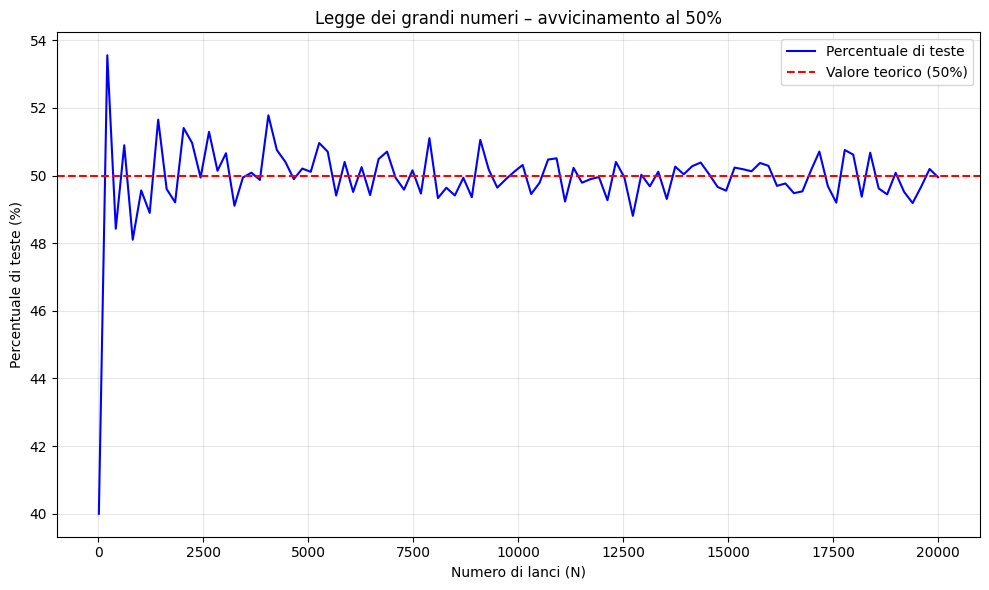

In [32]:

plt.figure(figsize=(10, 6))
plt.plot(N_values, percentuali, color="blue", label="Percentuale di teste")
plt.axhline(y=50, color="red", linestyle="--", label="Valore teorico (50%)")
plt.xlabel("Numero di lanci (N)")
plt.ylabel("Percentuale di teste (%)")
plt.title("Legge dei grandi numeri – avvicinamento al 50%")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

## 1. CELLA DEI CALCOLI

#### LEGGENDA

- **titanic.shape** → Restituisce una tupla (numero righe, numero colonne).

- **titanic.isnull().sum()** → Conta i valori nulli (NaN) per ogni colonna.

- **titanic["Embarked"].mode()[0]** → Calcola la moda (valore più frequente) della colonna; [0] prende il primo valore nel caso ci siano più mode.

- **titanic["Embarked"].fillna(moda_embarked, inplace=True)** → Sostituisce i NaN con la moda direttamente nel DataFrame.

- **titanic.duplicated().sum()** → Conta il numero di righe duplicate (considerando tutte le colonne).

- **titanic.groupby("Pclass")["Age"].mean()** → Raggruppa per Pclass e calcola la media di Age per ogni gruppo, ignorando i NaN.

- **titanic.groupby("Pclass")["Age"].transform("mean")** → Crea una Serie con la stessa lunghezza del DataFrame, dove ogni riga riceve la media della sua classe. Utile per riempire i NaN con la media del gruppo.

- **titanic["Age"].fillna(media_classe, inplace=True)** → Sostituisce i NaN in Age con i valori della Serie media_classe.

- **sns.boxplot(...)** → Crea un boxplot (scatola e baffi) per visualizzare la distribuzione di una variabile (qui Age) divisa per categorie (Pclass e opzionalmente Sex).



In [37]:
# Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# 1. Dimensioni del Dataset
righe, colonne = titanic.shape


# 2. Valori mancanti per colonna
valori_mancanti = titanic.isnull().sum()


# 3. Riempio la colonna 'Embarked' con la moda
moda_embarked = titanic["Embarked"]. mode()[0]
titanic["Embarked"].fillna(moda_embarked)


# 4. Controllo le righe duplicate
duplicati = titanic.duplicated().sum()


# 5. Età media per classe (prima di riempire i NaN)
eta_media = titanic.groupby("Pclass")["Age"].mean().round(2)


# 6. Riempio età mancanti con la media della rispettiva classe
media_classe = titanic.groupby("Pclass")["Age"].transform("mean")
titanic["Age"] = titanic["Age"].fillna(media_classe)
# Verifico che non ci siano piu NaN in Age
eta_mancanti_dopo = titanic["Age"].isnull().sum()


# Print finali

print(f"1. Il dataset ha {righe} righe e {colonne} colonne.\n")

print("2. Valori mancanti per colonna (prima della pulizia):")
for colonna, count in valori_mancanti[valori_mancanti > 0].items():
    print(f"   {colonna}: {count} valori mancanti")
print()

print(f"3. Colonna 'Embarked': riempita con la moda '{moda_embarked}'.\n")
print(f"4. Righe duplicate trovate: {duplicati}\n")

print("5. Età media per classe (prima del riempimento):")
for classe, media in eta_media.items():
    print(f"   Classe {classe}: età media = {media} anni")
print()

print(f"6. Dopo il riempimento, colonna 'Age' ha ancora {eta_mancanti_dopo} valori mancanti (dovrebbe essere 0).")



1. Il dataset ha 891 righe e 12 colonne.

2. Valori mancanti per colonna (prima della pulizia):
   Age: 177 valori mancanti
   Cabin: 687 valori mancanti
   Embarked: 2 valori mancanti

3. Colonna 'Embarked': riempita con la moda 'S'.

4. Righe duplicate trovate: 0

5. Età media per classe (prima del riempimento):
   Classe 1: età media = 38.23 anni
   Classe 2: età media = 29.88 anni
   Classe 3: età media = 25.14 anni

6. Dopo il riempimento, colonna 'Age' ha ancora 0 valori mancanti (dovrebbe essere 0).


## 2. CELLA DEI GRAFICI

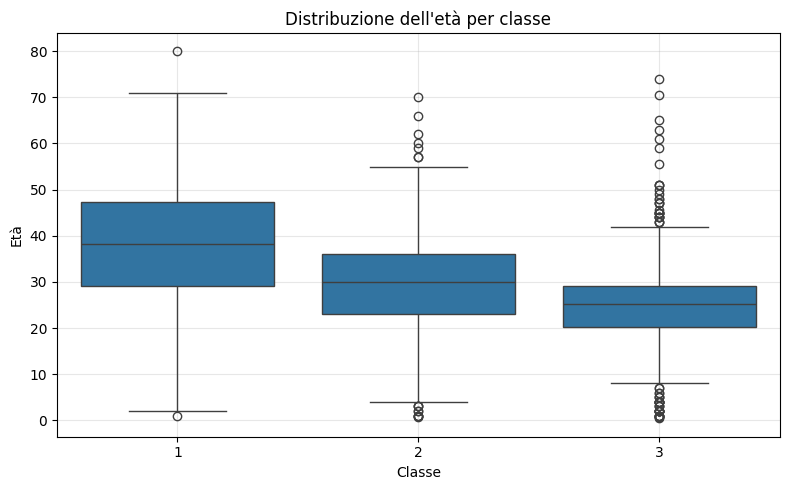

In [38]:
# Grafico 1 - Distribuzione dell'età per classe (boxplot)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Pclass", y="Age", data=titanic)
plt.title("Distribuzione dell'età per classe")
plt.xlabel("Classe")
plt.ylabel("Età")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

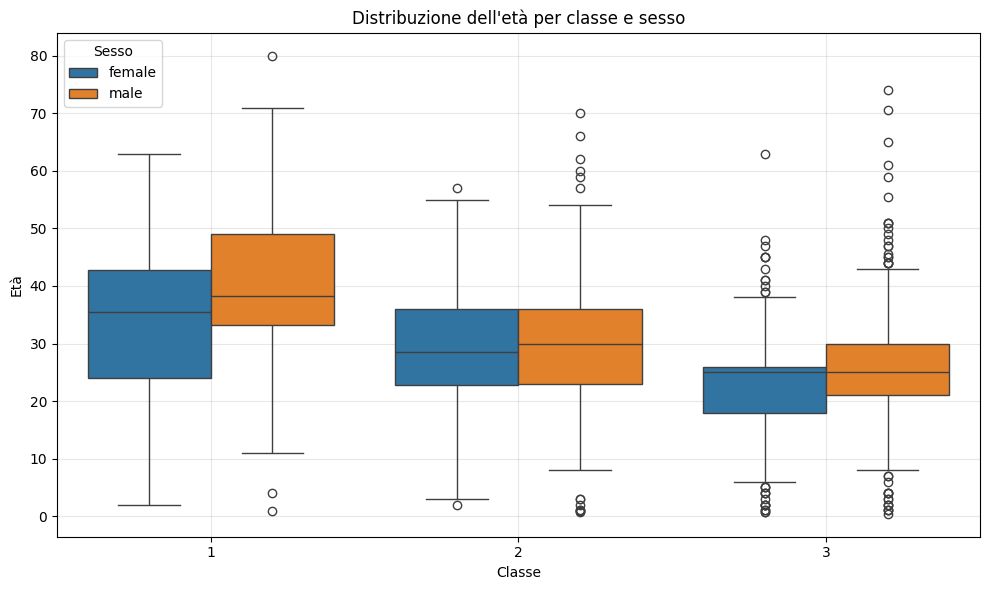

In [39]:
# Grafico 2 – Distribuzione dell'età per classe e sesso


plt.figure(figsize=(10, 6))
sns.boxplot(x="Pclass", y="Age", hue="Sex", data=titanic)
plt.title("Distribuzione dell'età per classe e sesso")
plt.xlabel("Classe")
plt.ylabel("Età")
plt.legend(title="Sesso")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

## 1. CELLA DEI CALCOLI

#### LEGGENDA

- **iris["species"].value_counts()** → Conta quante righe appartengono a ciascuna specie (utile per verificare il bilanciamento del dataset).

- **iris.groupby("species")["petal_length"].mean()** → Calcola la media della lunghezza del petalo per ogni specie.

- **iris["area_petalo"] = iris["petal_length"] * iris["petal_width"]** → Crea una nuova colonna moltiplicando lunghezza e larghezza.

- **sns.scatterplot(x=..., y=..., hue=..., data=...)** → Grafico a dispersione che distingue le specie con colori diversi.

- **sns.boxplot(...)** → Boxplot per visualizzare la distribuzione dell'area per specie (mediana, quartili, outlier).

In [43]:
# Carico il dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris = pd.read_csv(url)


# 1. Conto quanti campioni ci sono per specie
conteggio_specie = iris["species"].value_counts()


# 2. Faccio la media della lunghezza e larghezza del petalo per ogni specie
media_lunghezza = iris.groupby("species")["petal_length"].mean().round(2)
media_larghezza = iris.groupby("species")["petal_width"].mean().round(2)


# 3. Creo una nuova colonna: "Area del petalo" 
iris["area_petalo"] = iris["petal_length"] * iris["petal_width"]


# 4. Analizzo la nuova colonna
media_area = iris.groupby("species")["area_petalo"].mean().round(2)


# Printo tutto
print("1. Conteggio campioni per specie:")
for specie, count in conteggio_specie.items():
    print(f"   {specie}: {count}")
print()

print("2. Media lunghezza petalo per specie:")
for specie, media in media_lunghezza.items():
    print(f"   {specie}: {media} cm")
print()

print("3. Media larghezza petalo per specie:")
for specie, media in media_larghezza.items():
    print(f"   {specie}: {media} cm")
print()

print("4. Media area del petalo per specie:")
for specie, media in media_area.items():
    print(f"   {specie}: {media} cm²")

1. Conteggio campioni per specie:
   setosa: 50
   versicolor: 50
   virginica: 50

2. Media lunghezza petalo per specie:
   setosa: 1.46 cm
   versicolor: 4.26 cm
   virginica: 5.55 cm

3. Media larghezza petalo per specie:
   setosa: 0.25 cm
   versicolor: 1.33 cm
   virginica: 2.03 cm

4. Media area del petalo per specie:
   setosa: 0.37 cm²
   versicolor: 5.72 cm²
   virginica: 11.3 cm²


## 2. CELLA DEI GRAFICI

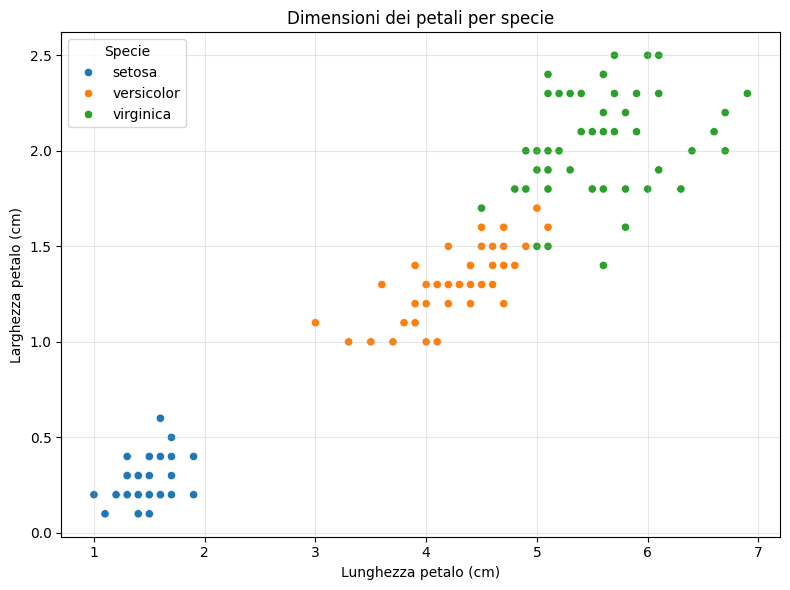

In [44]:
# Grafico 1 – Scatterplot delle dimensioni dei petali per specie

plt.figure(figsize=(8, 6))
sns.scatterplot(x="petal_length", y="petal_width", hue="species", data=iris)
plt.title("Dimensioni dei petali per specie")
plt.xlabel("Lunghezza petalo (cm)")
plt.ylabel("Larghezza petalo (cm)")
plt.legend(title="Specie")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

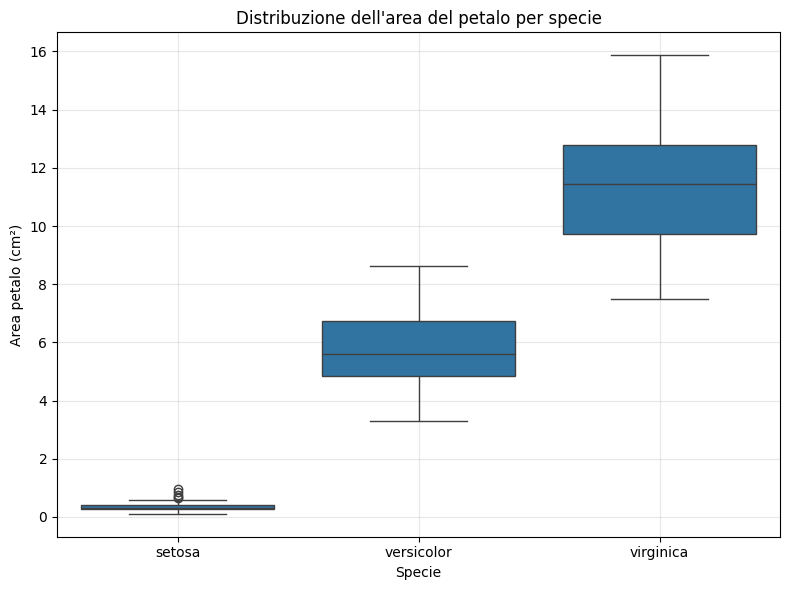

In [45]:
# Grafico 2 – Boxplot dell'area del petalo per specie

plt.figure(figsize=(8, 6))
sns.boxplot(x="species", y="area_petalo", data=iris)
plt.title("Distribuzione dell'area del petalo per specie")
plt.xlabel("Specie")
plt.ylabel("Area petalo (cm²)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()